In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [2]:
y_test=['A','A','A','B','A','B','A','B','B','A']
y_pred=['B','B','A','A','A','B','A','B','B','A']
df=pd.DataFrame({
   'Actual':y_test,
    'Predicted':y_pred
})
df

,Actual,Predicted
0,A,B
1,A,B
2,A,A
3,B,A
4,A,A
5,B,B
6,A,A
7,B,B
8,B,B
9,A,A


In [3]:
conf_matrix=confusion_matrix(y_test,y_pred)

Text(50.722222222222214, 0.5, 'Actual')

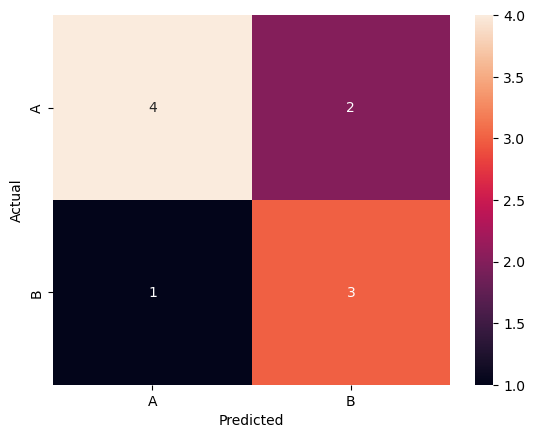

In [4]:
sns.heatmap(conf_matrix,annot=True,xticklabels=['A','B'],yticklabels=['A','B'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [5]:
TN=conf_matrix[0,0]
TP=conf_matrix[1,1]
FN=conf_matrix[1,0]
FP=conf_matrix[0,1]
TN,TP,FN,FP

(np.int64(4), np.int64(3), np.int64(1), np.int64(2))

In [6]:
accuracy=(TP+TN)/(TP+TN+FN+FP)
accuracy

np.float64(0.7)

In [7]:
precision=TP/(TP+FP)
precision

np.float64(0.6)

In [8]:
Specificity=TN/(TN+FP)
Specificity

np.float64(0.6666666666666666)

In [9]:
df=pd.get_dummies(df,drop_first=True)

In [10]:
df

,Actual_B,Predicted_B
0,False,True
1,False,True
2,False,False
3,True,False
4,False,False
5,True,True
6,False,False
7,True,True
8,True,True
9,False,False


In [11]:
accuracy_score(df['Actual_B'],df['Predicted_B'])

0.7

# FROM DIABETES FILE

In [12]:
df=pd.read_csv('diabetes.csv')

In [13]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [14]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
y=df[['Outcome']]
x=df.drop(columns='Outcome')

In [17]:
 x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [18]:
KNN=KNeighborsClassifier(n_neighbors=15)
KNN

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
KNN.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_pred=KNN.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [21]:
conf_matrix=confusion_matrix(y_test,y_pred)
conf_matrix

array([[104,  19],
       [ 31,  38]])

Text(50.722222222222214, 0.5, 'Actual')

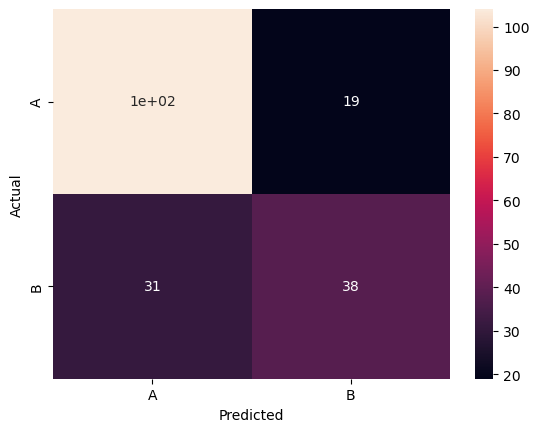

In [22]:
sns.heatmap(conf_matrix,annot=True,xticklabels=['A','B'],yticklabels=['A','B'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [23]:
TN=conf_matrix[0,0]
TP=conf_matrix[1,1]
FN=conf_matrix[1,0]
FP=conf_matrix[0,1]
TN,TP,FN,FP

(np.int64(104), np.int64(38), np.int64(31), np.int64(19))

In [24]:
accuracy=(TP+TN)/(TP+TN+FN+FP)
accuracy

np.float64(0.7395833333333334)

In [25]:
precision=TP/(TP+FP)
precision

np.float64(0.6666666666666666)

In [26]:
Specificity=TN/(TN+FP)
Specificity

np.float64(0.8455284552845529)

In [27]:
sensitivity=TP/(FN+TP)
sensitivity

np.float64(0.5507246376811594)

In [28]:
df=pd.get_dummies(df,drop_first=True)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
